# Layer 0: Data Provenance and EDA Audit

This notebook audits the input corpus. Ingestion logic lives in `src/data_loader.py`; this notebook checks data provenance, assumptions, quality, and the Layer 1 handoff.

Questions answered: What data did we start with? What are the ASRS export quirks? What assumptions did we make? Why does Layer 1 need STL seasonality handling?


<!-- notebook-rationale -->
## How to read this notebook

This notebook is the evidence trail for the data foundation. It is not trying to be a second implementation of the loader. The loader in `src/data_loader.py` owns ingestion behavior; this notebook answers the reviewer questions that usually come before modeling: where the data came from, whether the file format is trustworthy, which fields are complete enough to support the later layers, and whether there are temporal artifacts that would bias anomaly detection.

The key judgment call in Layer 0 is to treat ASRS as a leading qualitative safety signal, not as a complete incident census. ASRS is voluntary and self-selected, so absolute rates should be interpreted carefully. The system therefore emphasizes relative shifts, narrative emergence, and traceability to ACN records rather than claiming operational prevalence across all aviation.


In [25]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "outputs" / "data"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
RAW_DIR = PROJECT_ROOT / "data" / "raw"

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.25})


In [26]:
from src.data_loader import load_asrs_file
from src.spc import get_top_anomaly_categories

## Source and File Inventory

ASRS exports are downloaded from NASA as `.xls` files, but the files are tab-separated text with two header rows. The final local dataset uses **16 batch exports** covering primarily January 2018 through March 2026.


<!-- notebook-rationale -->
## Why the file inventory matters

The raw file count is not just bookkeeping. ASRS exports are manually downloaded in date windows, and an off-by-one file count can create reviewer doubt about coverage. The final corpus is based on 16 batch exports, so this notebook asserts that count when raw files are present locally.

Raw exports are intentionally not committed because they are large source data artifacts. The reproducible object for this repository is the merged parquet output. That split mirrors a production pattern: raw data lives in controlled storage, while code and derived metadata document how the analysis corpus is created.


In [27]:
raw_files = sorted(RAW_DIR.glob("*.xls")) + sorted(RAW_DIR.glob("*.xlsx"))
print(f"Raw export files found locally: {len(raw_files)}")
if raw_files:
    inventory = pd.DataFrame({"file": [p.name for p in raw_files], "size_mb": [round(p.stat().st_size / 1024**2, 2) for p in raw_files]})
    display(inventory)
    assert len(raw_files) == 16
else:
    print("Raw files are not committed; regenerate locally from NASA ASRS exports.")


Raw export files found locally: 16


,file,size_mb
0,ASRS_DBOnline_Jan18-June18.xls,6.53
1,ASRS_DBOnline_Jan19-June19.xls,6.69
2,ASRS_DBOnline_Jan20-Dec20.xls,12.11
3,ASRS_DBOnline_Jan21_June21.xls,6.09
4,ASRS_DBOnline_Jan22-June22.xls,7.51
5,ASRS_DBOnline_Jan23-June23.xls,5.97
6,ASRS_DBOnline_Jan24-Jun24.xls,7.05
7,ASRS_DBOnline_Jan25-June25.xls,7.65
8,ASRS_DBOnline_Jan26-Mar26.xls,1.65
9,ASRS_DBOnline_July18-Dec18.xls,7.93


## ASRS Format Sanity Check

The loader flattens the two-row export header into names such as `Aircraft 1 | Flight Phase`. This parser demonstration runs only when raw exports are present locally.


<!-- notebook-rationale -->
## Why the two-header-row parser is important

The `.xls` extension is misleading: these ASRS exports are tab-separated text files. Reading them as normal Excel would fail or create confusing columns. Reading them as TSV with two header rows preserves the hierarchy between column groups and fields.

Flattening headers into names like `Aircraft 1 | Flight Phase` is a deliberate design choice. It keeps the original ASRS grouping visible while giving the rest of the codebase stable, explicit column names. That improves auditability because a reviewer can trace each feature back to an ASRS export field.


In [28]:
if raw_files:
    sample = load_asrs_file(raw_files[0])
    print(f"Sample file: {raw_files[0].name}; shape: {sample.shape}")
    display(pd.DataFrame({"first_columns": sample.columns[:12]}))
else:
    print("Skipped raw-file parser demonstration because data/raw is not present.")


Sample file: ASRS_DBOnline_Jan18-June18.xls; shape: (2580, 126)


,first_columns
0,ACN
1,Time | Date
2,Time | Local Time Of Day
3,Place | Locale Reference
4,Place | State Reference
5,Place | Relative Position.Angle.Radial
6,Place | Relative Position.Distance.Nautical Miles
7,Place | Altitude.AGL.Single Value
8,Place | Altitude.MSL.Single Value
9,Place | Latitude / Longitude (UAS)


## Merged Corpus

Layer 0 writes `outputs/data/asrs_merged.parquet`. All downstream layers consume this canonical corpus rather than re-reading raw exports.


<!-- notebook-rationale -->
## Why the merged parquet is the handoff artifact

Every downstream layer reads a single canonical parquet file instead of re-reading raw exports. This avoids hidden divergence between notebooks, scripts, and modules. It also makes the pipeline faster and easier to validate: Layer 0 produces one dataset with known shape and derived fields, and Layer 1 starts from that stable boundary.

The shape assertion is intentional. If the row or column count changes, the notebook should fail loudly rather than silently allowing downstream counts to drift. For an interview case study, that is an important senior-engineering signal: assumptions are executable checks, not just prose.


In [29]:
merged_path = DATA_DIR / "asrs_merged.parquet"
assert merged_path.exists(), "Missing outputs/data/asrs_merged.parquet"
asrs = pd.read_parquet(merged_path)
asrs["date"] = pd.to_datetime(asrs["date"], errors="coerce")
summary = pd.DataFrame({"metric": ["records", "columns", "date_min", "date_max", "unique_acn"], "value": [f"{len(asrs):,}", asrs.shape[1], asrs["date"].min().strftime("%Y-%m"), asrs["date"].max().strftime("%Y-%m"), f"{asrs['ACN'].nunique():,}"]})
display(summary)
assert asrs.shape == (43829, 129)


,metric,value
0,records,"43,829"
1,columns,129
2,date_min,2002-06
3,date_max,2026-03
4,unique_acn,"43,829"


## Completeness of Fields Used Downstream

This check focuses on columns used by SPC, Isolation Forest, topic modeling, risk scoring, and RAG metadata.


<!-- notebook-rationale -->
## Why these fields are checked

The later layers use a mix of structured fields and text. SPC needs `Events | Anomaly`, Isolation Forest needs operational metadata, BERTopic and RAG need `full_narrative`, and Layer 3 needs narrative word content. A completeness check tells the reviewer whether the chosen features are defensible before any modeling begins.

The goal is not to maximize the number of features. It is to use a small set of high-signal fields that are present enough, interpretable enough, and tied directly to ASRS semantics. That is why the Isolation Forest uses flight phase, operator, detector/result, primary problem, and cyclic month rather than a large opaque feature matrix.


In [30]:
key_columns = {"ACN": "identifier", "date": "temporal anchor", "Events | Anomaly": "SPC taxonomy", "Aircraft 1 | Flight Phase": "IF/RAG metadata", "Aircraft 1 | Aircraft Operator": "IF feature", "Events | Detector": "IF feature", "Events | Result": "IF feature variant", "Events | Result 1": "IF feature variant", "Assessments | Primary Problem": "IF feature", "full_narrative": "NLP/RAG text", "narrative_word_count": "NLP quality filter"}
rows = [{"column": c, "role": r, "complete_pct": round(asrs[c].notna().mean() * 100, 1)} for c, r in key_columns.items() if c in asrs.columns]
display(pd.DataFrame(rows).sort_values("complete_pct"))


,column,role,complete_pct
4,Aircraft 1 | Aircraft Operator,IF feature,94.3
6,Events | Result,IF feature variant,95.8
3,Aircraft 1 | Flight Phase,IF/RAG metadata,96.5
5,Events | Detector,IF feature,97.3
7,Assessments | Primary Problem,IF feature,99.8
2,Events | Anomaly,SPC taxonomy,100.0
0,ACN,identifier,100.0
1,date,temporal anchor,100.0
8,full_narrative,NLP/RAG text,100.0
9,narrative_word_count,NLP quality filter,100.0


## Temporal Coverage and Seasonality

Layer 1 uses STL before CUSUM because ASRS volume is seasonal. This plot audits that design choice.


<!-- notebook-rationale -->
## Why seasonality changes the anomaly method

Aviation incident reporting has clear seasonal volume patterns. If CUSUM ran directly on raw monthly counts, expected seasonal peaks could look like alarms. Layer 1 therefore removes trend and seasonality with STL before applying CUSUM to residuals.

This is a modeling choice about false positives. In a safety workflow, too many seasonal false alarms would erode analyst trust. STL + CUSUM makes the alert more interpretable: the alarm means a category deviated from its expected seasonal pattern, not merely that summer traffic was busier.


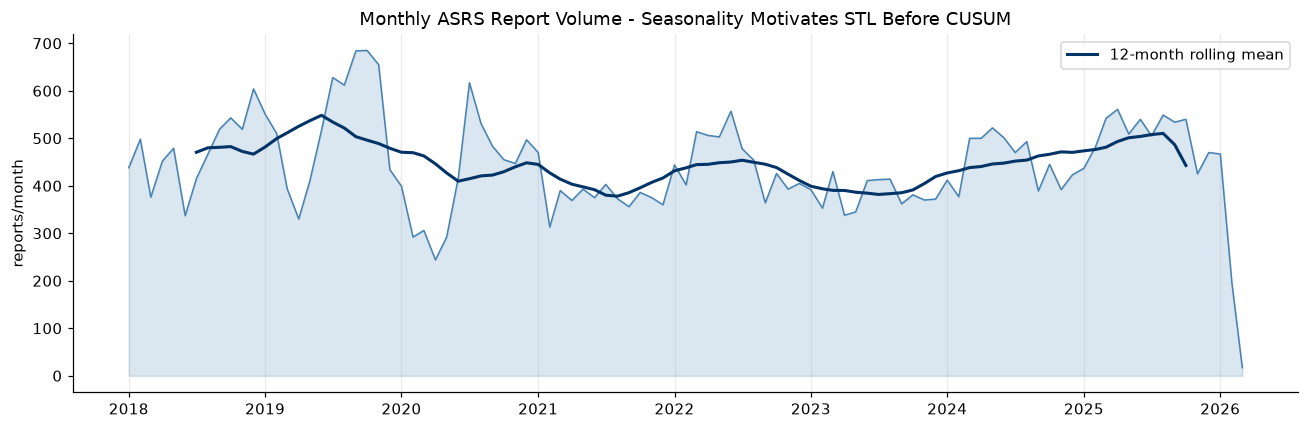

In [31]:
asrs_valid = asrs[asrs["date"].dt.year >= 2018].copy()
monthly = asrs_valid.groupby(asrs_valid["date"].dt.to_period("M"))["ACN"].count().to_timestamp()
rolling = monthly.rolling(12, center=True).mean()
fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(monthly.index, monthly.to_numpy(), alpha=0.2, color="steelblue")
ax.plot(monthly.index, monthly.to_numpy(), color="steelblue", linewidth=1)
ax.plot(rolling.index, rolling.to_numpy(), color="#003366", linewidth=2, label="12-month rolling mean")
ax.set_title("Monthly ASRS Report Volume - Seasonality Motivates STL Before CUSUM")
ax.set_ylabel("reports/month")
ax.legend()
plt.tight_layout()


## Taxonomy and Narrative Quality

The taxonomy powers Layer 1 SPC. The narrative field powers Layers 2-4.


<!-- notebook-rationale -->
## Why both structured taxonomy and narrative text are kept

The ASRS anomaly taxonomy gives stable, auditable categories for frequency monitoring. The narrative text captures weak signals before a formal taxonomy catches up. The architecture uses both because neither is sufficient alone: structured categories are reliable but can lag emerging risks, while narratives are rich but require semantic validation.

This dual view is the foundation of the project. Layer 1 uses structured fields to avoid keyword-driven novelty claims. Layer 2 independently checks whether the narratives form coherent semantic clusters. Layer 3 and Layer 4 then use the narrative for analyst prioritization and evidence retrieval.


In [32]:
top_categories = get_top_anomaly_categories(asrs, top_n=15)
display(pd.DataFrame({"category": top_categories.index, "incidents": top_categories.values, "pct_of_corpus": (top_categories.to_numpy(dtype=float) / len(asrs) * 100).round(1)}))
quality = pd.Series({"mean_words": round(asrs["narrative_word_count"].mean(), 1), "median_words": round(asrs["narrative_word_count"].median(), 1), "lt_30_words": int((asrs["narrative_word_count"] < 30).sum()), "gte_30_words": int((asrs["narrative_word_count"] >= 30).sum())})
display(quality.to_frame("value"))


,category,incidents,pct_of_corpus
0,Deviation / Discrepancy - Procedural Published...,24476,55.8
1,Aircraft Equipment Problem Critical,11465,26.2
2,Deviation / Discrepancy - Procedural Clearance,8780,20.0
3,ATC Issue All Types,7097,16.2
4,Aircraft Equipment Problem Less Severe,6842,15.6
5,Deviation / Discrepancy - Procedural FAR,5271,12.0
6,Conflict NMAC,4194,9.6
7,Inflight Event / Encounter CFTT / CFIT,3942,9.0
8,Inflight Event / Encounter Weather / Turbulence,3664,8.4
9,Ground Event / Encounter Loss Of Aircraft Control,2930,6.7


,value
mean_words,296.7
median_words,222.0
lt_30_words,862.0
gte_30_words,42967.0


## Layer 0 to Layer 1 Handoff

Layer 0 produces `outputs/data/asrs_merged.parquet` with `date`, `full_narrative`, and `narrative_word_count`. Layer 1 consumes this corpus to compute exact-category SPC alarms, structured Isolation Forest novelty, and the 2x2 quadrant.


<!-- notebook-rationale -->
## What Layer 1 inherits

Layer 1 inherits a clean corpus, not a modeling conclusion. The important handoff fields are `date`, `Events | Anomaly`, operational metadata, and `full_narrative`. Layer 1 then deliberately separates frequency anomaly from behavioral novelty.

That separation matters because it prevents one signal from doing too much. Frequency shifts are handled by SPC. Structured novelty is handled by Isolation Forest. Narrative emergence is used as a supporting storyline and later validated semantically in Layer 2.
